# CLL and MGL comparison

In [ ]:
import pyccl as ccl
import numpy as np
import matplotlib.pyplot as plt
import MGLensing

# my_colors = ['#7AC011', '#18698F', '#FF7083', '#99D4E5']
my_colors = ['#8ECAE6', '#035177', '#FFDD03', "#78206E", '#F58300']

kmax07 = [482, 616, 716, 780, 818]
kmax03 = [206, 264, 306, 334, 350]
kmax01 = [68, 88, 102, 111, 116]

MGL = MGLensing.MGL("config_ccl_comparison.yaml")
# MGL Cells 
ell_l = MGL.Survey.l_wl
ell_g = MGL.Survey.l_gc
ell_x = MGL.Survey.l_xc
zz_integr = MGL.Survey.zz_integr  #512 points for better agreement
dndz_sources = MGL.Survey.eta_z_s
dndz_lenses = MGL.Survey.eta_z_l
nbin = MGL.Survey.nbin

# set IA to 0
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    # 'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.96,
    'h'         : 0.68,
    'Mnu'       : 0.0,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'b1_1': 1.239,
    'b1_2': 1.378,
    'b1_3': 1.525,
    'b1_4': 1.677,
    'b1_5': 1.832,
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121,
    'b1L_4': 0.60626,
    'b1L_5': 0.779385,
    'b2L_1': -0.1322075,
    'b2L_2': -0.0345375,
    'b2L_3': 0.0579305,
    'b2L_4': 0.133662,
    'b2L_5': 0.232387,
    'bs2L_1': 0.1127485,
    'bs2L_2': 0.0036835,
    'bs2L_3': -0.1261985,
    'bs2L_4': -0.285537,
    'bs2L_5': -0.406101,
    'blaplL_1': -0.100126,
    'blaplL_2': -0.1563475,
    'blaplL_3': -0.115281,
    'blaplL_4': 0.1059295,
    'blaplL_5': 0.361450,
    'a1_IA'   : 0., #0.67,
    'eta1_IA' : 0., #1.66,
    'beta_IA' : 0.,
}     
model = {
    'nl_model' : 1,
    'bias_model' : 2,
    'baryon_model' : 0,
    'ia_model' : 0,
    'photoz_err_model' : 0
}


## Matter power spectrum

In [2]:
# MGL power spectra
k_arr, pmm_mgl, pgm_mgl, pgg_mgl = MGL.get_power_spectra(params, model)

# CCL initialization
bemu_nl = ccl.BaccoemuNonlinear()
cosmo_nl = ccl.Cosmology(Omega_c=params['Omega_c'], 
                         Omega_b=params['Omega_b'], 
                         h=params['h'], 
                         n_s=params['ns'], 
                         sigma8=params['sigma8_cb'],
                        #  A_s=params['As'],
                         m_nu=params['Mnu'], 
                         w0=params['w0'],
                         wa=params['wa'],
                         Omega_k = 0.,
                         T_ncdm=0,
                         transfer_function='boltzmann_camb',
                         matter_power_spectrum=bemu_nl
                         )

# CCL non linear matter power spectrum with Bacco
pk_nl_bemu = cosmo_nl.get_nonlin_power()

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

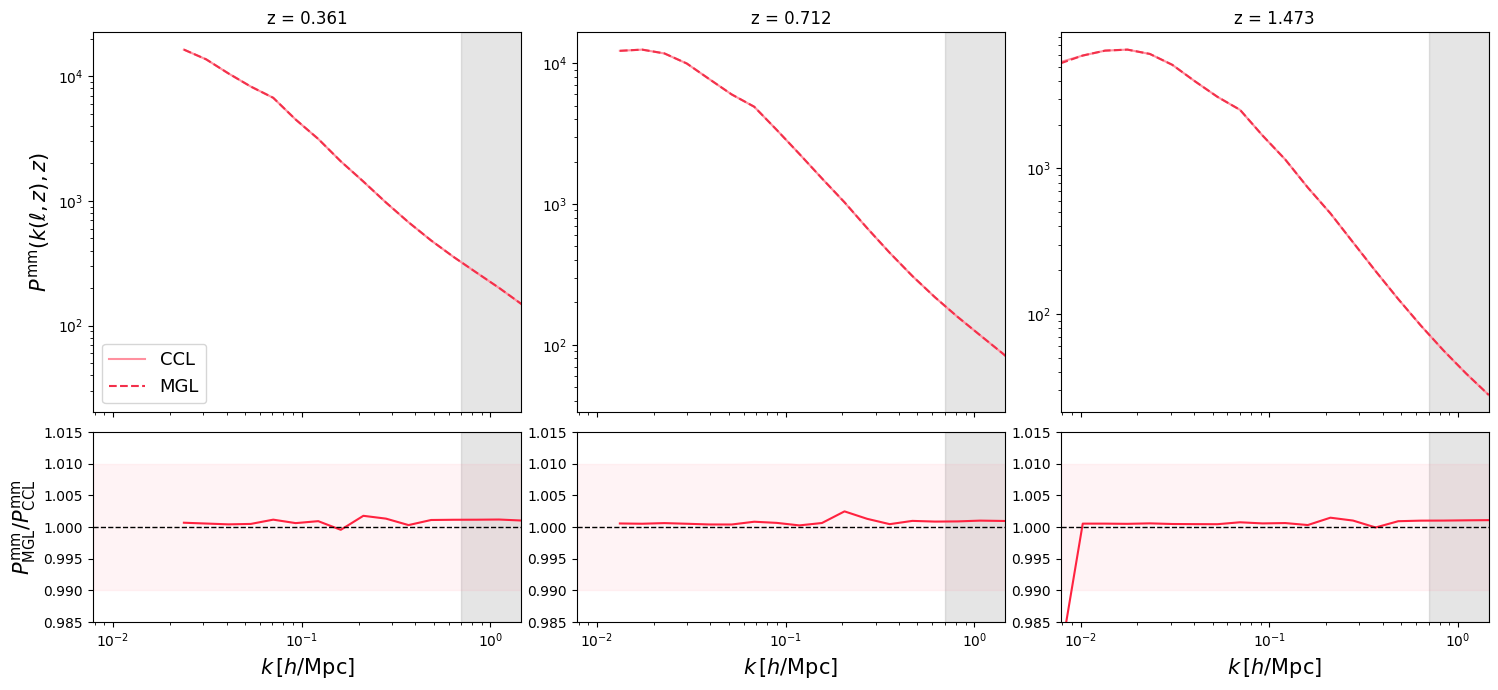

In [3]:
z_indices = [60, 120, 250]  
a_z = []
for z in z_indices:
    a_z.append(1 / (1 + zz_integr[z]))

fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for i in range(len(z_indices)):
    k = k_arr[:,z_indices[i]]
    pmm_nl_ccl = pk_nl_bemu(k*params['h'], a_z[i], cosmo_nl)* params['h']**3
    ax[0][i].loglog(k, pmm_nl_ccl, color="#FF909F", label='CCL')
    ax[0][i].loglog(k, pmm_mgl[:,z_indices[i]], color="#F3304A", linestyle='--', label='MGL')
    ax[0][i].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[0][i].set_title(f'z = {zz_integr[z_indices[i]]:.3f}')                                              # WHY THE REDSHIFT VALUES ARE DIFFERENT FROM MARIA'S IF WE PEAKED THE SAME INDICES?????
    #
    ax[1][i].plot(k, pmm_mgl[:,z_indices[i]]/pmm_nl_ccl, color='#FF223F')
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][i].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][i].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[1][i].axhspan(0.99, 1.01, color='#FF909F', alpha=0.1, label='_nolegend_')
    ax[1][i].set_xlim(k[0], k[-1])
    ax[1][i].set_ylim(0.985, 1.015)
ax[0][0].legend(fontsize=13)
ax[0][0].set_ylabel("$P^{\\rm mm}(k(\ell, z), z)$", fontsize=15)
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm MGL}/P_{\\rm CCL}^{\\rm mm}$", fontsize=15)
plt.tight_layout()

The difference here is the same we saw already and it's on the MGL documentation (orange line). Weird thing: the Pmm for CCL was computed using halofit, while here we're using Bacco NL for both MGL and CCL Pmm, so I expect them to agree more.

## Galaxy power spectrum

In [4]:
h = params['h']
min_k = np.log10(2.e-4 * h)  # from MGL bacco_interface
max_k = np.log10(0.7 * h)
# with Bacco HEFT 
heft = ccl.nl_pt.BaccoLbiasCalculator(cosmo=cosmo_nl, log10k_min=min_k, log10k_max=max_k, nk_per_decade=20)
heft.update_ingredients(cosmo_nl)

b1_arr = np.array([params[f'b1_{i+1}'] for i in range(nbin)])
b1L = np.array([params[f'b1L_{i+1}']+1 for i in range(nbin)])
b2L = np.array([params[f'b2L_{i+1}']*2 for i in range(nbin)])
bs2 = np.array([params[f'bs2L_{i+1}']*2 for i in range(nbin)])
bLap = np.array([params[f'blaplL_{i+1}']*2 for i in range(nbin)])

bias_ia = params['a1_IA'] * (1.+zz_integr)**params['eta1_IA'] * 0.0134/0.01387684609

# get HEFT Pgg
pk_gg_ccl = [[None for j in range(nbin)] for i in range(nbin)]
pk_gl_ccl = [[None for j in range(nbin)] for i in range(nbin)]
for i in range(nbin):
    for j in range(nbin):
        ptt_g_i = ccl.nl_pt.PTNumberCountsTracer(b1=(zz_integr, b1L[i]*np.ones(len(zz_integr))), b2=(zz_integr, b2L[i]*np.ones(len(zz_integr))), 
                                            bs=(zz_integr, bs2[i]*np.ones(len(zz_integr))), bk2=(zz_integr, bLap[i]*np.ones(len(zz_integr))))
        ptt_g_j = ccl.nl_pt.PTNumberCountsTracer(b1=(zz_integr, b1L[j]*np.ones(len(zz_integr))), b2=(zz_integr, b2L[j]*np.ones(len(zz_integr))), 
                                            bs=(zz_integr, bs2[j]*np.ones(len(zz_integr))), bk2=(zz_integr, bLap[j]*np.ones(len(zz_integr))))
        ptt_l_j = ccl.nl_pt.PTMatterTracer()
        pk_gg_ccl[i][j] = heft.get_biased_pk2d(tracer1=ptt_g_i, tracer2=ptt_g_j)
        pk_gl_ccl[i][j] = heft.get_biased_pk2d(tracer1=ptt_g_i, tracer2=ptt_l_j)

Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.


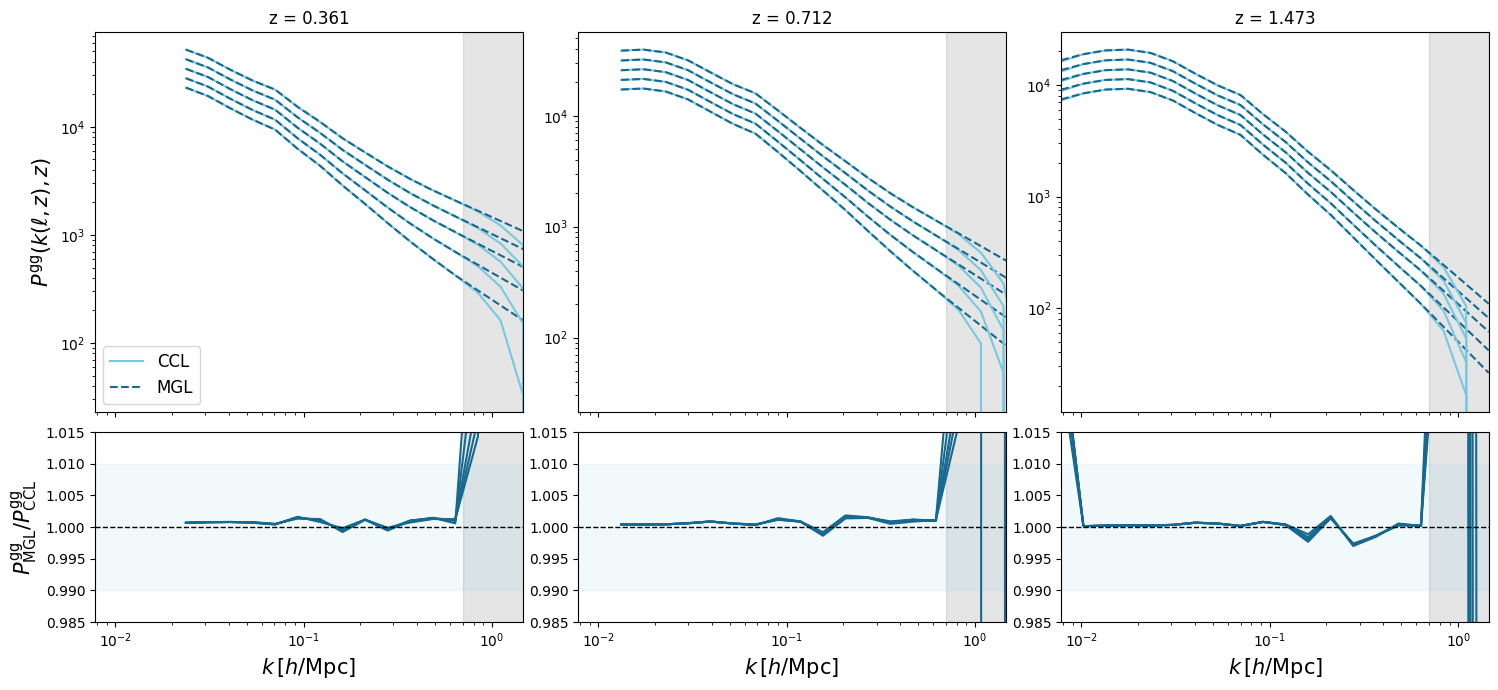

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for z in range(len(z_indices)):
    k = k_arr[:,z_indices[z]]
    for i in range(nbin):
        pgg_ccl = pk_gg_ccl[i][i](k*params['h'], a_z[z], cosmo_nl)* params['h']**3
        ax[0][z].loglog(k, pgg_ccl, color="#76C9E0")
        ax[0][z].loglog(k, pgg_mgl[:,z_indices[z],i,i], color='#18698F', linestyle='--')
        #
        ax[1][z].plot(k, pgg_mgl[:,z_indices[z],i,i]/pgg_ccl, color='#18698F')
    ax[0][z].set_title(f'z = {zz_integr[z_indices[z]]:.3f}')
    ax[0][z].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    
    ax[1][z].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][z].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][z].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[1][z].axhspan(0.99, 1.01, color='#76C9E0', alpha=0.1, label='_nolegend_')
    ax[1][z].set_xlim(k[0], k[-1])
    ax[1][z].set_ylim(0.985, 1.015)
legend = ['CCL', 'MGL']
ax[0][0].legend(legend, fontsize=12)
ax[0][0].set_ylabel("$P^{\\rm gg}(k(\ell, z), z)$", fontsize=15)
ax[1][0].set_ylabel("$P^{\\rm gg}_{\\rm MGL}/P_{\\rm CCL}^{\\rm gg}$", fontsize=15)
plt.tight_layout()

## Angular power spectrum

In [ ]:
# Cells with MGL
cl_ll_mgl, cl_gg_mgl, cl_lg_mgl, cl_gl_mgl = MGL.get_c_ells(params, model)
err_cl_ll, err_cl_gg, err_cl_gl = MGL.get_errorbars(params)

# get CCL Cells with HEFT Pgg
cl_ll_ccl = np.zeros((len(ell_l), nbin, nbin))
cl_gg_ccl = np.zeros((len(ell_g), nbin, nbin))
cl_gl_ccl = np.zeros((len(ell_x), nbin, nbin))
bias_ia = params['a1_IA'] * (1.+zz_integr)**params['eta1_IA'] * 0.0134/0.01387684609
# bias_g = np.array([1.187256, 1.312369, 1.451258, 1.605669, 1.777521])
bias_g = np.ones_like(zz_integr)

# define tracers
for i in range(nbin):
    t_g_i = ccl.NumberCountsTracer(cosmo_nl, has_rsd=False, dndz=(zz_integr, dndz_lenses[:,i]), 
                                       bias=(zz_integr, bias_g), mag_bias=None)
    t_l_i = ccl.WeakLensingTracer(cosmo_nl, dndz=(zz_integr, dndz_sources[:,i]), ia_bias=(zz_integr, bias_ia))
    for j in range(nbin):
        t_g_j = ccl.NumberCountsTracer(cosmo_nl, has_rsd=False, dndz=(zz_integr, dndz_lenses[:,j]), 
                                       bias=(zz_integr, bias_g), mag_bias=None)
        t_l_j = ccl.WeakLensingTracer(cosmo_nl, dndz=(zz_integr, dndz_sources[:,j]), ia_bias=(zz_integr, bias_ia))
        # get Cl_ij (in principle I don't need to make a tracer i and j, but it's better here because of how dndz is built in MGL)
        cl_ll_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, t_l_i, t_l_j, ell_l)
        cl_gg_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, t_g_i, t_g_j, ell_g, p_of_k_a=pk_gg_ccl[i][j])  
        cl_gl_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, t_g_i, t_l_j, ell_x, p_of_k_a=pk_gl_ccl[i][j])
        

# add noise to diagonal components (noise=0 for WLxGC)
for i in range(nbin):
    cl_ll_ccl[:,i,i] += MGL.Survey.noise['LL']
    cl_gg_ccl[:,i,i] += MGL.Survey.noise['GG']

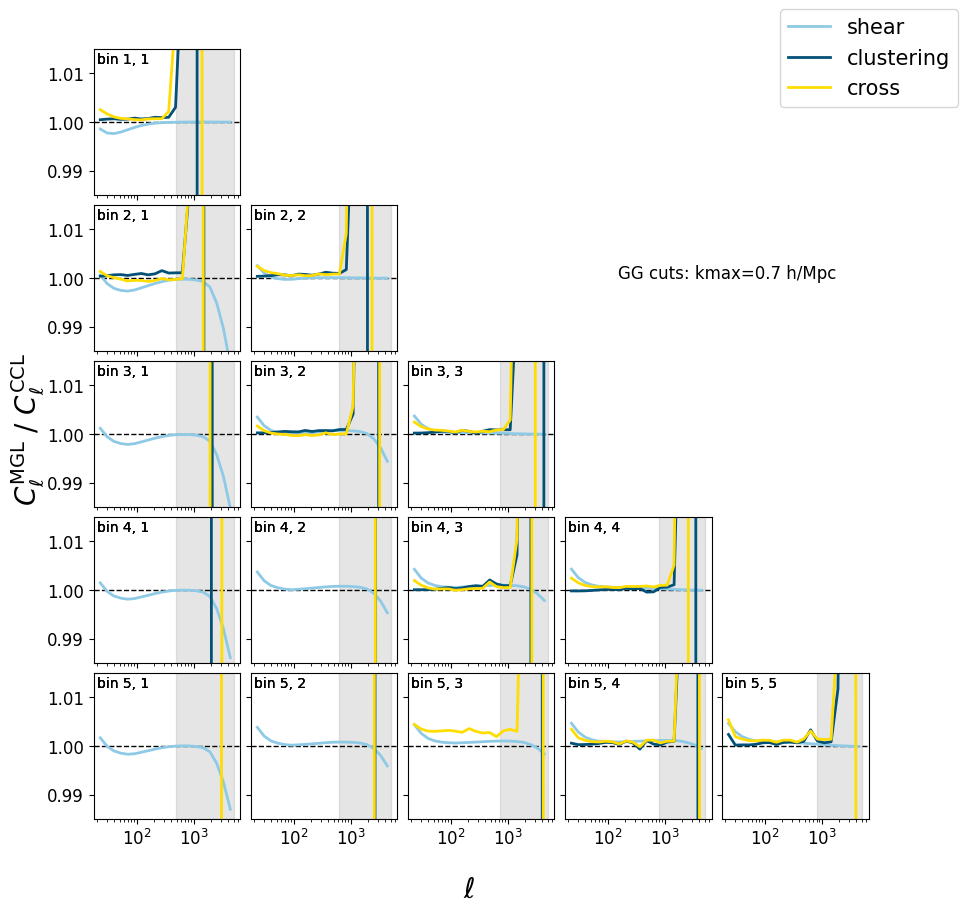

In [ ]:
ell_cuts = [kmax07]
ell_list = [ell_l, ell_g, ell_x]
cl_mgl_list = [cl_ll_mgl, cl_gg_mgl, cl_gl_mgl]
cl_ccl_list = [cl_ll_ccl, cl_gg_ccl, cl_gl_ccl]
fig, ax = plt.subplots(nbin, nbin, figsize=(10, 10), sharey='row', sharex=True)
fig.subplots_adjust(wspace=0.07, hspace=0.07)
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i][j].axhline(y=1.0, color='k', linestyle='--', linewidth=1, label='_nolegend_')   
            for idx in range(len(cl_mgl_list)):
                ax[i,j].plot(ell_list[idx], cl_mgl_list[idx][:,i,j]/cl_ccl_list[idx][:,i,j], color=my_colors[idx], linewidth=2)  #/err[idx][:,i,j]
                ax[i,j].set_xscale('log')
                ax[i,j].text(.2, .9, f'bin {i+1}, {j+1}', fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  
                ax[i,j].tick_params(axis='both', which='major', labelsize=12)        
                # ax[i,j].set_xlim(18, 1000)
                ax[i,j].set_ylim(0.985, 1.015)
            for cuts in ell_cuts:
                ax[i,j].axvspan(5000, cuts[j], color='grey', alpha=0.2, label='_nolegend_') #GG cuts
                # ax[i,j].axvspan(2000, 5000, color='grey', alpha=0.1, label='_nolegend_') #LL cuts
                # ax[i,j].axvspan(0, 20, color='grey', alpha=0.1, label='_nolegend_') #LL cuts
        else:
            ax[i,j].axis('off')
ax[1,1].annotate('GG cuts: kmax=0.7 h/Mpc', (2.5, 0.5), xycoords='axes fraction', clip_on=False, fontsize=12)     

fig.text(0.06, 0.5, r'$C_\ell^{\rm MGL}$ / $C_\ell^{\rm CCL}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)  
fig.legend(['shear', 'clustering', 'cross'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=15)

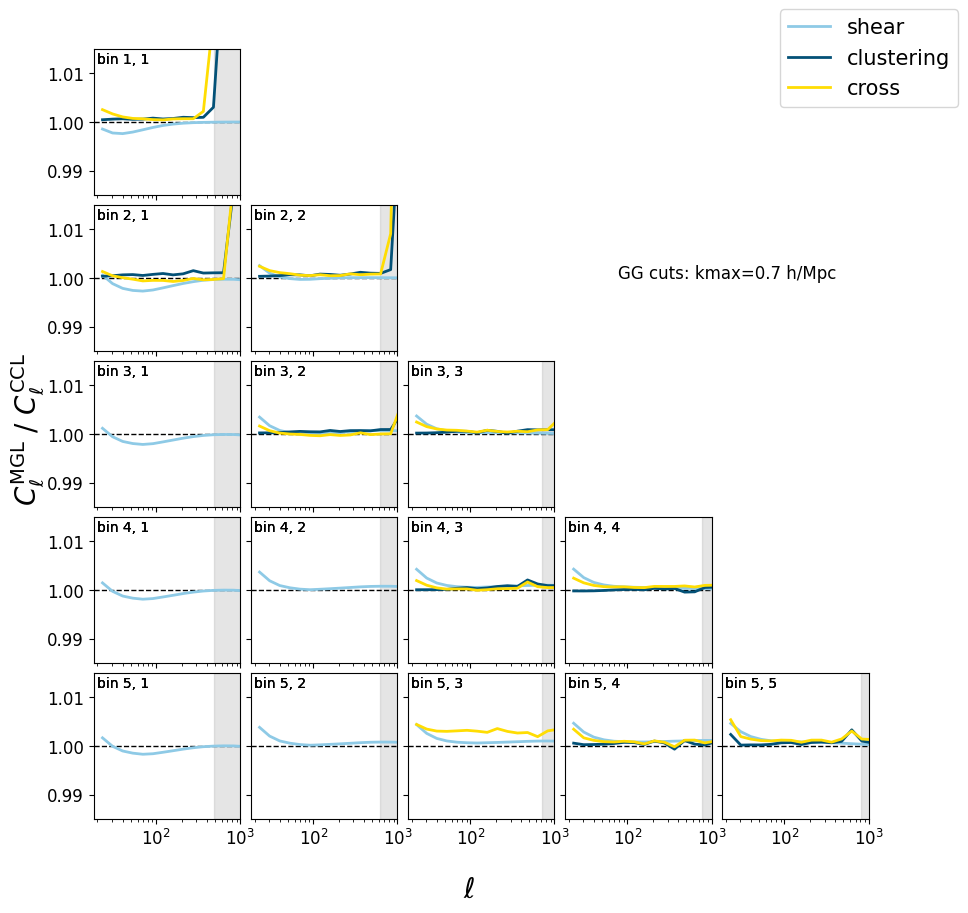

In [8]:
ell_cuts = [kmax07]
ell_list = [ell_l, ell_g, ell_x]
cl_mgl_list = [cl_ll_mgl, cl_gg_mgl, cl_gl_mgl]
cl_ccl_list = [cl_ll_ccl, cl_gg_ccl, cl_gl_ccl]
fig, ax = plt.subplots(nbin, nbin, figsize=(10, 10), sharey='row', sharex=True)
fig.subplots_adjust(wspace=0.07, hspace=0.07)
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i][j].axhline(y=1.0, color='k', linestyle='--', linewidth=1, label='_nolegend_')   
            for idx in range(len(cl_mgl_list)):
                ax[i,j].plot(ell_list[idx], cl_mgl_list[idx][:,i,j]/cl_ccl_list[idx][:,i,j], color=my_colors[idx], linewidth=2)  #/err[idx][:,i,j]
                ax[i,j].set_xscale('log')
                ax[i,j].text(.2, .9, f'bin {i+1}, {j+1}', fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  
                ax[i,j].tick_params(axis='both', which='major', labelsize=12)        
                ax[i,j].set_xlim(18, 1000)
                ax[i,j].set_ylim(0.985, 1.015)
            for cuts in ell_cuts:
                ax[i,j].axvspan(5000, cuts[j], color='grey', alpha=0.2, label='_nolegend_') #GG cuts
                # ax[i,j].axvspan(2000, 5000, color='grey', alpha=0.1, label='_nolegend_') #LL cuts
                # ax[i,j].axvspan(0, 20, color='grey', alpha=0.1, label='_nolegend_') #LL cuts
        else:
            ax[i,j].axis('off')
ax[1,1].annotate('GG cuts: kmax=0.7 h/Mpc', (2.5, 0.5), xycoords='axes fraction', clip_on=False, fontsize=12)     

fig.text(0.06, 0.5, r'$C_\ell^{\rm MGL}$ / $C_\ell^{\rm CCL}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)  
fig.legend(['shear', 'clustering', 'cross'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=15)

## Need to fix implementation of CCL in MGL:
- there is a memory error -> rise when computing the tracer t_g_i 
- this notebook works, where is the difference?
- remember to fix 3 functions in theory and in \_init_